# NSE F&O Database Assignment

using the kaggle dataset for NSE futures and options data (3 months)
building a relational DB with 4 tables and running some analysis on it

dataset link - https://www.kaggle.com/datasets/sunnysai12345/nse-future-and-options-dataset-3m

In [1]:
!pip install duckdb pandas matplotlib -q

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load the csv
df = pd.read_csv('fo_data.csv')
print(df.shape)
df.head(3)

(73027, 16)


,Unnamed: 0,INSTRUMENT,SYMBOL,EXPIRY_DT,STRIKE_PR,OPTION_TYP,OPEN,HIGH,LOW,CLOSE,SETTLE_PR,CONTRACTS,VAL_INLAKH,OPEN_INT,CHG_IN_OI,TIMESTAMP
0,160393,FUTIDX,BANKNIFTY,29-Aug-2019,0.0,XX,28805.65,28924.00,28140.55,28499.30,28499.30,214569,1225914.96,1675780.0,234640.0,01-AUG-2019
1,160394,FUTIDX,BANKNIFTY,26-Sep-2019,0.0,XX,28926.40,29030.55,28251.70,28611.45,28611.45,2484,14245.95,51400.0,-80.0,01-AUG-2019
2,160395,FUTIDX,BANKNIFTY,31-Oct-2019,0.0,XX,29000.00,29105.00,28355.55,28699.05,28699.05,598,3434.43,9460.0,4860.0,01-AUG-2019


In [4]:
# checking column names first before renaming
print(df.columns.tolist())

['Unnamed: 0', 'INSTRUMENT', 'SYMBOL', 'EXPIRY_DT', 'STRIKE_PR', 'OPTION_TYP', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'SETTLE_PR', 'CONTRACTS', 'VAL_INLAKH', 'OPEN_INT', 'CHG_IN_OI', 'TIMESTAMP']


In [5]:
# lowercase all columns
df.columns = [c.lower() for c in df.columns]

# rename to match schema
df = df.rename(columns={
    'instrument':  'instrument_type',
    'open':        'open_pr',
    'high':        'high_pr',
    'low':         'low_pr',
    'close':       'close_pr',
    'option_typ':  'option_type',
    'timestamp':   'trade_date',
    'val_inlakh':  'val_in_lakh',
})

# dates - using dayfirst because indian date format is DD-MM-YYYY
# errors=coerce turns bad dates into NaT instead of crashing
df['trade_date'] = pd.to_datetime(df['trade_date'], dayfirst=True, errors='coerce')
df['expiry_dt']  = pd.to_datetime(df['expiry_dt'],  dayfirst=True, errors='coerce')

# drop rows where date parsing failed
before = len(df)
df = df.dropna(subset=['trade_date'])
print(f'dropped {before - len(df)} bad rows')

# futures dont have option type, kaggle uses '-' for that
df['option_type'] = df['option_type'].replace('-', None)

# futures also dont have a strike price, 0 means null here
df['strike_pr'] = df['strike_pr'].replace(0.0, None)

df['exchange_code'] = 'NSE'

print('rows:', len(df))
print('date range:', df['trade_date'].min(), 'to', df['trade_date'].max())
print(df['instrument_type'].value_counts())

dropped 1 bad rows
rows: 73026
date range: 2019-08-01 00:00:00 to 2019-11-01 00:00:00
instrument_type
OPTSTK    60560
OPTIDX    11085
FUTSTK     1354
FUTIDX       27
Name: count, dtype: int64


/tmp/ipykernel_352/2595575809.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trade_date'] = pd.to_datetime(df['trade_date'], dayfirst=True, errors='coerce')


## creating the database

going with 4 tables instead of keeping everything flat
main reason - NIFTY would appear like 50k+ times in a flat table, waste of space
also easier to add BSE/MCX later without changing the whole structure

exchanges → instruments → expiries → trades

In [6]:
con = duckdb.connect('fo_database.duckdb')

con.execute('''
    CREATE TABLE IF NOT EXISTS exchanges (
        exchange_id   INTEGER PRIMARY KEY,
        exchange_code VARCHAR(10) UNIQUE NOT NULL,
        exchange_name VARCHAR(100),
        country       VARCHAR(50) DEFAULT 'India',
        currency      CHAR(3)     DEFAULT 'INR'
    )
''')

# adding NSE BSE MCX even though dataset only has NSE
# schema is ready for multi exchange
con.execute('''
    INSERT OR IGNORE INTO exchanges VALUES
        (1, 'NSE', 'National Stock Exchange', 'India', 'INR'),
        (2, 'BSE', 'Bombay Stock Exchange',   'India', 'INR'),
        (3, 'MCX', 'Multi Commodity Exchange','India', 'INR')
''')

con.execute('SELECT * FROM exchanges').df()

,exchange_id,exchange_code,exchange_name,country,currency
0,1,NSE,National Stock Exchange,India,INR
1,2,BSE,Bombay Stock Exchange,India,INR
2,3,MCX,Multi Commodity Exchange,India,INR


In [7]:
# instruments - unique symbols
# joining to exchanges to get the proper exchange_id
con.execute('''
    CREATE TABLE IF NOT EXISTS instruments AS
    SELECT
        ROW_NUMBER() OVER (ORDER BY d.symbol, d.instrument_type) AS instrument_id,
        e.exchange_id,
        d.symbol,
        d.instrument_type,
        NULL::VARCHAR  AS underlying,
        NULL::INTEGER  AS lot_size
    FROM (
        SELECT DISTINCT symbol, instrument_type, exchange_code FROM df
    ) d
    JOIN exchanges e ON e.exchange_code = d.exchange_code
''')

print('instruments:', con.execute('SELECT COUNT(*) FROM instruments').fetchone()[0])
con.execute('SELECT * FROM instruments LIMIT 5').df()

instruments: 328


,instrument_id,exchange_id,symbol,instrument_type,underlying,lot_size
0,1,1,ACC,FUTSTK,None,<NA>
1,2,1,ACC,OPTSTK,None,<NA>
2,3,1,ADANIENT,FUTSTK,None,<NA>
3,4,1,ADANIENT,OPTSTK,None,<NA>
4,5,1,ADANIPORTS,FUTSTK,None,<NA>


In [8]:
# expiries - each unique contract
# one contract = symbol + expiry date + strike price + CE or PE
# for futures strike and option_type are null
con.execute('''
    CREATE TABLE IF NOT EXISTS expiries AS
    SELECT
        ROW_NUMBER() OVER (ORDER BY i.instrument_id, d.expiry_dt, d.strike_pr) AS expiry_id,
        i.instrument_id,
        d.expiry_dt,
        d.strike_pr,
        d.option_type
    FROM (
        SELECT DISTINCT symbol, instrument_type, exchange_code,
                        expiry_dt, strike_pr, option_type
        FROM df
    ) d
    JOIN exchanges   e ON e.exchange_code  = d.exchange_code
    JOIN instruments i ON i.exchange_id    = e.exchange_id
                     AND i.symbol          = d.symbol
                     AND i.instrument_type = d.instrument_type
''')

print('expiries:', con.execute('SELECT COUNT(*) FROM expiries').fetchone()[0])

expiries: 70410


In [9]:
# trades - the main table with all daily price data
con.execute('''
    CREATE TABLE IF NOT EXISTS trades AS
    SELECT
        ROW_NUMBER() OVER () AS trade_id,
        ex.expiry_id,
        d.trade_date,
        d.open_pr,
        d.high_pr,
        d.low_pr,
        d.close_pr,
        d.settle_pr,
        d.contracts,
        d.val_in_lakh,
        d.open_int,
        d.chg_in_oi
    FROM df d
    JOIN exchanges   e  ON e.exchange_code  = d.exchange_code
    JOIN instruments i  ON i.exchange_id    = e.exchange_id
                      AND i.symbol          = d.symbol
                      AND i.instrument_type = d.instrument_type
    JOIN expiries    ex ON ex.instrument_id = i.instrument_id
                      AND ex.expiry_dt      = d.expiry_dt
                      AND (ex.strike_pr     IS NOT DISTINCT FROM d.strike_pr)
                      AND (ex.option_type   IS NOT DISTINCT FROM d.option_type)
''')

print('final row counts:')
for t in ['exchanges','instruments','expiries','trades']:
    c = con.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t:15s} {c:>10,}')

final row counts:
  exchanges                3
  instruments            328
  expiries            70,410
  trades              73,026


## queries

running 7 queries on the data

In [10]:
# query 1 - top 10 symbols by OI change
# OI = open interest, total active contracts
# big OI change means big money entering or exiting

q1 = con.execute('''
    SELECT
        i.symbol,
        e.exchange_code,
        t.trade_date,
        i.instrument_type,
        SUM(t.open_int)  AS total_oi,
        SUM(t.chg_in_oi) AS total_oi_change,
        RANK() OVER (
            PARTITION BY t.trade_date
            ORDER BY ABS(SUM(t.chg_in_oi)) DESC
        ) AS oi_rank
    FROM trades t
    JOIN expiries    ex ON t.expiry_id      = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    JOIN exchanges   e  ON i.exchange_id    = e.exchange_id
    WHERE t.trade_date = (SELECT MAX(trade_date) FROM trades)
    GROUP BY i.symbol, e.exchange_code, t.trade_date, i.instrument_type
    ORDER BY ABS(total_oi_change) DESC
    LIMIT 10
''').df()
q1

,symbol,exchange_code,trade_date,instrument_type,total_oi,total_oi_change,oi_rank
0,IDEA,NSE,2019-11-01,FUTSTK,563836000.0,46564000.0,1
1,YESBANK,NSE,2019-11-01,OPTSTK,106312800.0,29442600.0,2
2,IDEA,NSE,2019-11-01,OPTSTK,200928000.0,19180000.0,3
3,DISHTV,NSE,2019-11-01,FUTSTK,102056300.0,14724300.0,4
4,BANKINDIA,NSE,2019-11-01,OPTSTK,17868000.0,12186000.0,5
5,NIFTY,NSE,2019-11-01,OPTIDX,86320750.0,11999625.0,6
6,SAIL,NSE,2019-11-01,OPTSTK,26796000.0,9468000.0,7
7,SBIN,NSE,2019-11-01,OPTSTK,51198000.0,8631000.0,8
8,PNB,NSE,2019-11-01,OPTSTK,28112000.0,8561000.0,9
9,DISHTV,NSE,2019-11-01,OPTSTK,12600000.0,7406000.0,10


In [11]:
# query 2 - 7 day rolling volatility for NIFTY options
# stddev over 7 days = how much prices are swinging
# PARTITION BY expiry_id means we track each contract separately

q2 = con.execute('''
    SELECT
        t.trade_date,
        ex.option_type,
        ex.strike_pr,
        ex.expiry_dt,
        t.close_pr,
        ROUND(
            STDDEV(t.close_pr) OVER (
                PARTITION BY ex.expiry_id
                ORDER BY t.trade_date
                ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
            ),
        2) AS rolling_7d_stddev,
        ROUND(
            AVG(t.close_pr) OVER (
                PARTITION BY ex.expiry_id
                ORDER BY t.trade_date
                ROWS BETWEEN 6 PRECEDING AND CURRENT ROW
            ),
        2) AS rolling_7d_avg
    FROM trades t
    JOIN expiries    ex ON t.expiry_id      = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    JOIN exchanges   e  ON i.exchange_id    = e.exchange_id
    WHERE i.symbol          = 'NIFTY'
      AND i.instrument_type = 'OPTIDX'
      AND e.exchange_code   = 'NSE'
    ORDER BY ex.strike_pr, t.trade_date
    LIMIT 30
''').df()
q2

,trade_date,option_type,strike_pr,expiry_dt,close_pr,rolling_7d_stddev,rolling_7d_avg
0,2019-08-01,PE,4600.0,2020-06-25,83.25,NaN,83.25
1,2019-08-01,CE,4600.0,2020-12-31,3955.65,NaN,3955.65
2,2019-08-01,PE,4600.0,2020-12-31,86.90,NaN,86.90
3,2019-08-01,PE,4600.0,2019-12-26,2.00,NaN,2.00
4,2019-08-01,CE,4600.0,2019-12-26,3683.20,NaN,3683.20
5,2019-08-01,CE,4600.0,2020-06-25,3820.25,NaN,3820.25
6,2019-11-01,CE,4600.0,2020-06-25,3820.25,0.0,3820.25
7,2019-11-01,PE,4600.0,2020-06-25,83.25,0.0,83.25
8,2019-11-01,PE,4600.0,2019-12-26,2.00,0.0,2.00
9,2019-11-01,CE,4600.0,2019-12-26,3683.20,0.0,3683.20


In [12]:
# query 3 - cross type settle price comparison
# dataset only has NSE data so cant do MCX gold vs NSE
# doing index futures vs stock futures instead, same concept
# schema already has MCX in exchanges table, just need the data

q3 = con.execute('''
    WITH index_fut AS (
        SELECT t.trade_date,
               ROUND(AVG(t.settle_pr), 2) AS avg_settle,
               SUM(t.contracts)           AS contracts
        FROM trades t
        JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        WHERE i.instrument_type = 'FUTIDX'
        GROUP BY t.trade_date
    ),
    stock_fut AS (
        SELECT t.trade_date,
               ROUND(AVG(t.settle_pr), 2) AS avg_settle,
               SUM(t.contracts)           AS contracts
        FROM trades t
        JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        WHERE i.instrument_type = 'FUTSTK'
        GROUP BY t.trade_date
    )
    SELECT
        COALESCE(a.trade_date, b.trade_date) AS trade_date,
        a.avg_settle  AS index_fut_settle,
        b.avg_settle  AS stock_fut_settle,
        a.contracts   AS index_contracts,
        b.contracts   AS stock_contracts
    FROM index_fut a
    FULL OUTER JOIN stock_fut b ON a.trade_date = b.trade_date
    ORDER BY trade_date DESC
    LIMIT 20
''').df()
q3

,trade_date,index_fut_settle,stock_fut_settle,index_contracts,stock_contracts
0,2019-11-01,19366.69,1912.49,266703.0,1013108.0
1,2019-10-01,18639.46,1766.31,628647.0,1307478.0
2,2019-08-01,18393.71,1564.43,424506.0,855525.0


In [13]:
# query 4 - option chain for NIFTY
# same view you see on zerodha - calls on one side puts on other
# PCR = put call ratio, above 1 means more puts = bearish

q4 = con.execute('''
    SELECT
        ex.expiry_dt,
        ex.strike_pr,
        SUM(CASE WHEN ex.option_type = 'CE' THEN t.contracts ELSE 0 END) AS call_volume,
        SUM(CASE WHEN ex.option_type = 'CE' THEN t.open_int  ELSE 0 END) AS call_oi,
        ROUND(AVG(CASE WHEN ex.option_type = 'CE' THEN t.close_pr END), 2) AS call_ltp,
        SUM(CASE WHEN ex.option_type = 'PE' THEN t.contracts ELSE 0 END) AS put_volume,
        SUM(CASE WHEN ex.option_type = 'PE' THEN t.open_int  ELSE 0 END) AS put_oi,
        ROUND(AVG(CASE WHEN ex.option_type = 'PE' THEN t.close_pr END), 2) AS put_ltp,
        ROUND(
            SUM(CASE WHEN ex.option_type = 'PE' THEN t.open_int ELSE 0 END) * 1.0 /
            NULLIF(SUM(CASE WHEN ex.option_type = 'CE' THEN t.open_int ELSE 0 END), 0),
        3) AS pcr
    FROM trades t
    JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    WHERE i.symbol     = 'NIFTY'
      AND t.trade_date = (SELECT MAX(trade_date) FROM trades)
    GROUP BY ex.expiry_dt, ex.strike_pr
    HAVING (call_oi + put_oi) > 0
    ORDER BY ex.expiry_dt, ex.strike_pr
    LIMIT 20
''').df()
q4

,expiry_dt,strike_pr,call_volume,call_oi,call_ltp,put_volume,put_oi,put_ltp,pcr
0,2019-11-07,9200.0,0.0,0.0,1581.80,45.0,7050.0,0.40,NaN
1,2019-11-07,9250.0,0.0,0.0,1532.70,8007.0,375.0,0.65,NaN
2,2019-11-07,9300.0,0.0,0.0,1598.25,38.0,675.0,0.20,NaN
3,2019-11-07,9350.0,0.0,0.0,1604.75,9213.0,975.0,0.40,NaN
4,2019-11-07,9400.0,0.0,0.0,1556.80,1.0,75.0,0.75,NaN
5,2019-11-07,9450.0,0.0,0.0,1509.10,0.0,450.0,0.45,NaN
6,2019-11-07,9500.0,0.0,0.0,1461.65,604.0,300.0,0.95,NaN
7,2019-11-07,9550.0,0.0,0.0,1414.50,22413.0,225.0,0.30,NaN
8,2019-11-07,9600.0,0.0,0.0,1367.70,6002.0,75.0,0.30,NaN
9,2019-11-07,10000.0,0.0,0.0,1009.20,56.0,1275.0,0.70,NaN


In [14]:
# query 5 - max volume in last 30 days
# grouping by symbol + date then ordering by contracts desc
# efficient because only scans the 30 day window not full table

last_date = con.execute('SELECT MAX(trade_date) FROM trades').fetchone()[0]

q5 = con.execute(f'''
    SELECT
        i.symbol,
        i.instrument_type,
        t.trade_date,
        MAX(t.contracts)   AS max_contracts,
        SUM(t.val_in_lakh) AS total_value
    FROM trades t
    JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    WHERE t.trade_date >= DATE \'{last_date}\' - INTERVAL 30 DAYS
    GROUP BY i.symbol, i.instrument_type, t.trade_date
    ORDER BY max_contracts DESC
    LIMIT 15
''').df()
q5

,symbol,instrument_type,trade_date,max_contracts,total_value
0,BANKNIFTY,OPTIDX,2019-11-01,432225,28078672.55
1,NIFTY,OPTIDX,2019-11-01,253520,22528632.47
2,BANKNIFTY,FUTIDX,2019-11-01,164740,1009303.90
3,YESBANK,FUTSTK,2019-11-01,106665,166610.94
4,NIFTY,FUTIDX,2019-11-01,96819,893633.23
5,ZEEL,FUTSTK,2019-11-01,45715,175756.40
6,IBULHSGFIN,FUTSTK,2019-11-01,41825,73530.71
7,SBIN,FUTSTK,2019-11-01,26913,257412.49
8,TATASTEEL,FUTSTK,2019-11-01,26714,112679.35
9,INDUSINDBK,FUTSTK,2019-11-01,26322,145038.10


In [15]:
# explain plan for query 5
# shows how duckdb is actually running the query internally

plan = con.execute(f'''
    EXPLAIN
    SELECT i.symbol, t.trade_date, MAX(t.contracts) AS max_contracts
    FROM trades t
    JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    WHERE t.trade_date >= DATE \'{last_date}\' - INTERVAL 30 DAYS
    GROUP BY i.symbol, t.trade_date
    ORDER BY max_contracts DESC
    LIMIT 15
''').fetchall()

for row in plan:
    print(row[1])

┌───────────────────────────┐
│           TOP_N           │
│    ────────────────────   │
│          Top: 15          │
│                           │
│         Order By:         │
│   max(t.contracts) DESC   │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│__internal_decompress_strin│
│           g(#0)           │
│             #1            │
│             #2            │
│                           │
│          ~8 Rows          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│       HASH_GROUP_BY       │
│    ────────────────────   │
│          Groups:          │
│             #0            │
│             #1            │
│                           │
│    Aggregates: max(#2)    │
│                           │
│          ~8 Rows          │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│         PROJECTION        │
│    ────────────────────   │
│           symbol          │
│         

In [16]:
# query 6 - top 5 strikes by OI for BANKNIFTY
# high OI at a strike = market expects price to stay near that level
# this is how max pain is calculated

q6 = con.execute('''
    WITH oi_by_strike AS (
        SELECT
            ex.expiry_dt,
            ex.strike_pr,
            ex.option_type,
            SUM(t.open_int) AS strike_oi,
            SUM(SUM(t.open_int)) OVER (
                PARTITION BY ex.expiry_dt, ex.option_type
            ) AS total_expiry_oi,
            RANK() OVER (
                PARTITION BY ex.expiry_dt, ex.option_type
                ORDER BY SUM(t.open_int) DESC
            ) AS rnk
        FROM trades t
        JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        WHERE i.symbol     = 'BANKNIFTY'
          AND t.trade_date = (SELECT MAX(trade_date) FROM trades)
          AND ex.option_type IS NOT NULL
        GROUP BY ex.expiry_dt, ex.strike_pr, ex.option_type
    )
    SELECT
        expiry_dt,
        option_type,
        strike_pr,
        strike_oi,
        ROUND(100.0 * strike_oi / NULLIF(total_expiry_oi, 0), 2) AS pct_of_total,
        rnk
    FROM oi_by_strike
    WHERE rnk <= 5
    ORDER BY expiry_dt, option_type, rnk
''').df()
q6

,expiry_dt,option_type,strike_pr,strike_oi,pct_of_total,rnk
0,2019-11-07,CE,31000.0,587060.0,20.69,1
1,2019-11-07,CE,30500.0,300480.0,10.59,2
2,2019-11-07,CE,31500.0,272600.0,9.61,3
3,2019-11-07,CE,30800.0,164160.0,5.78,4
4,2019-11-07,CE,30000.0,152900.0,5.39,5
...,...,...,...,...,...,...
643,2020-01-30,PE,31300.0,0.0,NaN,1
644,2020-01-30,PE,31400.0,0.0,NaN,1
645,2020-01-30,PE,31500.0,0.0,NaN,1
646,2020-01-30,PE,31700.0,0.0,NaN,1


In [17]:
# query 7 - NIFTY near month futures settle price
# picking the nearest expiry for each date
# futures price should converge to spot as expiry approaches

q7 = con.execute('''
    WITH near_fut AS (
        SELECT
            t.trade_date,
            i.symbol,
            ex.expiry_dt,
            AVG(t.settle_pr) AS futures_settle,
            (ex.expiry_dt - CAST(t.trade_date AS DATE)) AS days_to_expiry
        FROM trades t
        JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
        JOIN instruments i  ON ex.instrument_id = i.instrument_id
        WHERE i.symbol          = 'NIFTY'
          AND i.instrument_type = 'FUTIDX'
          AND ex.expiry_dt      >= CAST(t.trade_date AS DATE)
        GROUP BY t.trade_date, i.symbol, ex.expiry_dt
    ),
    ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY trade_date
                ORDER BY days_to_expiry ASC
            ) AS rn
        FROM near_fut
    )
    SELECT trade_date, symbol, expiry_dt,
           ROUND(futures_settle, 2) AS futures_settle,
           days_to_expiry
    FROM ranked
    WHERE rn = 1
    ORDER BY trade_date DESC
    LIMIT 20
''').df()
q7

,trade_date,symbol,expiry_dt,futures_settle,days_to_expiry
0,2019-11-01,NIFTY,2019-11-28,11928.25,27 days
1,2019-10-01,NIFTY,2019-10-31,11429.85,30 days
2,2019-08-01,NIFTY,2019-08-29,11015.35,28 days


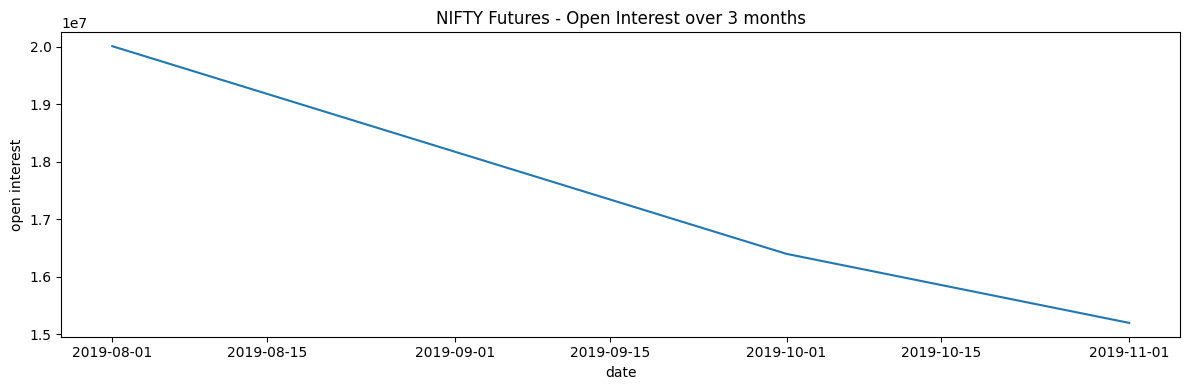

In [18]:
# quick chart - NIFTY futures OI over the 3 months

nifty_oi = con.execute('''
    SELECT t.trade_date, SUM(t.open_int) AS total_oi
    FROM trades t
    JOIN expiries    ex ON t.expiry_id     = ex.expiry_id
    JOIN instruments i  ON ex.instrument_id = i.instrument_id
    WHERE i.symbol = 'NIFTY' AND i.instrument_type = 'FUTIDX'
    GROUP BY t.trade_date
    ORDER BY t.trade_date
''').df()

plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(nifty_oi['trade_date']), nifty_oi['total_oi'])
plt.title('NIFTY Futures - Open Interest over 3 months')
plt.xlabel('date')
plt.ylabel('open interest')
plt.tight_layout()
plt.savefig('nifty_oi_chart.png', dpi=120)
plt.show()

In [20]:
con.close()
print('assignment done')

assignment done
